# Module 2: dask & xarray for computing weather and climate diagnostics
Sarah Henry

## Assignment details:

Task:
Create code using python `xarray` to organize and reduce climate data.  The goal of this analysis will be to detect global atmospheric circulation patterns (or teleconnections) associated with extreme daily precipitation in a certain part of the globe. You will 

1. Use the precipitation output of ERA-5 to compute a time series of daily precipitation at a given point closest to a city of your choosing. Choose a box of 5 x 5 deg lat-lon values over the grid box closest to the city you are examining.  Save this data.  Use a period of at least 10 years.

2. Determine the 95% values of daily precipitation for the data created in (1).  Plot a *cumulative distribution function* of all values daily precipitation values and illustrate the 95% value of daily precipitation in millimeters.

3. Create a map of the composite mean precipitation on the 95% days identified in (2) over the continental USA, and a map of the anomaly of precipitation from the 1981-2010 mean. This field should be plotted on a Cartopy map centered at your city with a 40 x 40 degree lat-lon range.

Functionality Requirements:
* The code must use `dask` and `xarray` for the data reduction, and `matplotlib` to plot the required visualizations.
* You can develop the code using a Jupyter Notebook, or any other way; the repository should be submitted to GitHub, and include a descriptive README.md.

Formatting and Documentation Requirements:
* The appropriate references for the data, including DOI numbers, for the datasets used.  
* The code must contain docstrings and comments where appropriate.
* The code must be formatted in PEP8.

GitHub usage requirements:
* The code must be submitted to GitHub Classroom.  


Import statements.

In [66]:
import xarray as xr
import dask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.diagnostics import ProgressBar
import numpy as np

## 1. 
Use the precipitation output of ERA-5 to compute a time series of daily precipitation at a given point closest to a city of your choosing. Choose a box of 5 x 5 deg lat-lon values over the grid box closest to the city you are examining.  Save this data.  Use a period of at least 10 years.

**City: Lansing, MI**

Set up dask.

In [2]:
from dask.distributed import Client
client = Client()  # set up local cluster on your machine
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37163,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44639,Total threads: 1
Dashboard: http://127.0.0.1:46387/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:33841,


Process the data into daily precipitation data for Owase, Japan. (Takes a while, about 10 min)

In [23]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)
ds = ds.sel(time=slice("1990-01-01","2000-01-01"))

# total_precipitation
precip_da = ds["total_precipitation"]

city_name = "Lansing"
city_lat = 42.72079
city_lon =  360-84.47413

def get_daily_data_lat_lon_slice(data, lat, lon, bbox):
    """Returns the total daily (sum) data for a region
        with a defined bounding box



    Args:
        data (xarray.DataSet or xarray.DataArray): _description_
        lat (float): central latitude
        lon (float): central longitude
        bbox (float): bounding box centered around lat, lon 
            (e.g. a 5x5 degree box)

    Returns:
        xarray.DataSet or DataArray: daily summed data for defined region
    """    
    # select just a 5x5 degree box around desired city
    data_slice = data.sel(
        latitude=slice(lat + bbox / 2, lat - bbox / 2),
        longitude=slice(lon - bbox / 2, lon + bbox / 2),
    )

    # resample and sum the hourly precip for total daily precip
    daily_data = data_slice.resample(time="1D").sum(keep_attrs=True)

    return daily_data

# precip_daily_da = get_daily_data_lat_lon_slice(precip_da, city_lat, city_lon, 5.)
# precip_daily_ds = precip_daily_da.to_dataset(name="tp")
# precip_daily_ds.to_netcdf(f"./datasets/precip_{city_name}_daily_1990-2000.nc")

precip_daily_da = xr.open_dataset(f"./datasets/precip_{city_name}_daily_1990-2020.nc")

## 2. 
Determine the 95% values of daily precipitation for the data created in (1).  Plot a *cumulative distribution function* of all values daily precipitation values and illustrate the 95% value of daily precipitation in millimeters.


Build the CDF.

In [10]:
precip_daily_mm = precip_daily_da * 1000  # m to mm
q95 = precip_daily_mm.quantile(0.95, dim=["time", "latitude", "longitude"], skipna=True).compute()
precip_daily_mm_flat = precip_daily_mm.stack(z=("time","latitude","longitude"))

def get_CDF(data):
    """Build a CDF from a flattened dataarray

    Args:
        data (xarray.Dataarray): flattened dataarray
    """   
    values = data.values
    values = values[np.isfinite(values)]
    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted)+1) / len(values_sorted)

    return values_sorted, cdf


values, cdf = get_CDF(precip_daily_mm_flat)

Plot the CDF.

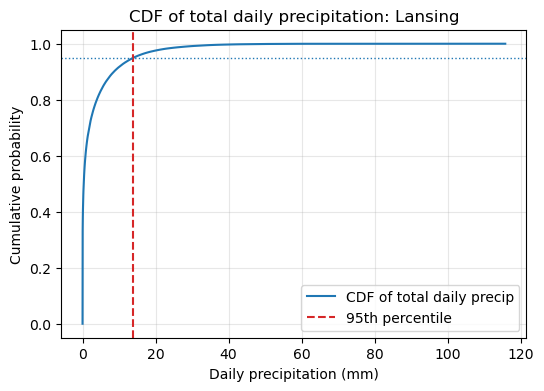

In [26]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(values, cdf, label="CDF of total daily precip")
ax.axvline(float(q95.values), color="tab:red", linestyle="--", label="95th percentile")
ax.axhline(0.95, color="tab:blue", linestyle=":", linewidth=1)

ax.set_xlabel("Daily precipitation (mm)")
ax.set_ylabel("Cumulative probability")
ax.set_title(f"CDF of total daily precipitation: {city_name}")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

## 3. 
Create a map of the composite mean precipitation on the 95% days identified in (2) over the continental USA, and a map of the anomaly of precipitation from the 1981-2010 mean. This field should be plotted on a Cartopy map centered at your city with a 40 x 40 degree lat-lon range.


Open the climatology dataset.


In [ ]:
# provided
precip_monthly_ds = xr.open_dataset('https://www.atmos.illinois.edu/~snesbitt/data/ERA-5_total_precipitation_monthly-1981-2020.nc', engine='h5netcdf')
# ds_climo.to_netcdf('./datasets/precip_global_monthly-1990-2020.nc')

Get the 40x40 daily precip data

In [ ]:
precip_daily_US_da = get_daily_data_lat_lon_slice(precip_da, city_lat, city_lon, 40.)
precip_daily_US_ds = precip_daily_US_da.to_dataset(name="tp")
# precip_daily_US_ds.to_netcdf("./datasets/precip_US_daily_1990-2000.nc")

Identify days where the total daily precipitation exceeds climatology in Lansing

In [ ]:
precip_city_daily = precip_daily_mm.mean(["latitude", "longitude"])
days_city_greater_than_q95 = precip_city_daily["time"].where(city_daily >= q95, drop=True)
days_US_greater_than_q95 = precip_daily_US_da.where(days_city_greater_than_q95.time == precip_daily_US_da.time)
days_US_greater_than_q95_mean = days_US_greater_than_q95.mean(dim="time")

Plot the composite mean precipitation on the 95% days.

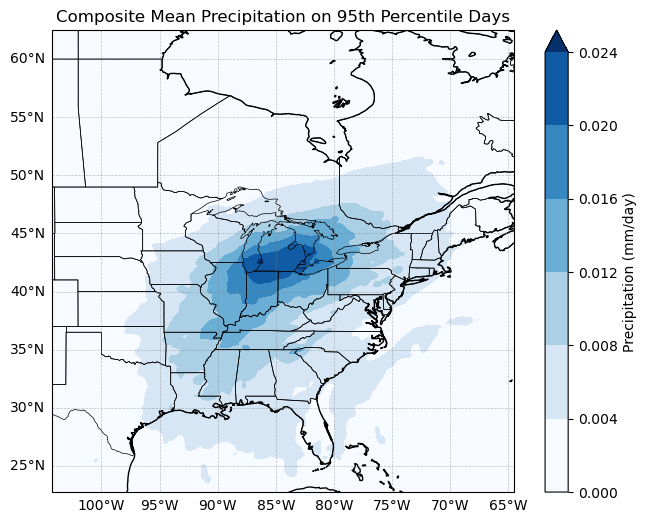

In [68]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

days_US_greater_than_q95_mean.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    cbar_kwargs={"label": "Precipitation (mm/day)"},
    levels=np.arange(0,.028,0.004)
)
ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="black")
ax.set_title("Composite Mean Precipitation on 95th Percentile Days")
plt.show()

Calculate the anomaly from the cooresponding month's climatology.

In [ ]:
precip_monthly_clim = precip_monthly_ds.groupby("valid_time.month").mean(dim="valid_time")
precip_daily_anom = (
    days_US_greater_than_q95.groupby("time.month") 
    - precip_monthly_clim
).mean(dim="time")["tp"]

Plot the anomaly of precipitation from the climatology.

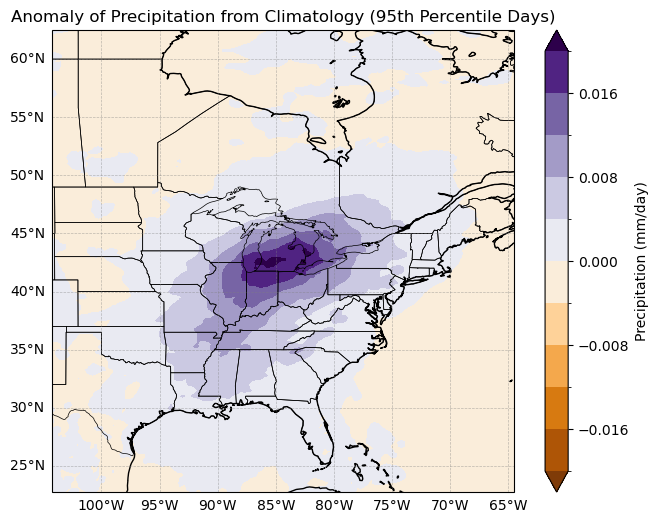

In [69]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

precip_daily_anom["tp"].plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="PuOr",
    cbar_kwargs={"label": "Precipitation (mm/day)"},
    levels=np.arange(-.02,.02+.004,.004),
    extend="both"
)

ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="black")
ax.set_title("Anomaly of Precipitation from Climatology (95th Percentile Days)")
plt.show()